#### **Import des bibliothèques**

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS

#### **Préparer les données (FORMAT TRÈS IMPORTANT)**
``statsforecast`` exige 3 colonnes:
| Colonne     | Rôle                    |
| ----------- | ----------------------- |
| `unique_id` | Identifiant de la série |
| `ds`        | Date                    |
| `y`         | Valeur                  |

In [72]:
df = pd.read_csv("../data/meteo.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.rename(columns={
    'Date': 'ds',
    'Temp': 'y'
})
df['unique_id'] = 'Serie_1'
df.head()


,ds,y,unique_id
0,1981-01-01,20.7,Serie_1
1,1981-01-02,17.9,Serie_1
2,1981-01-03,18.8,Serie_1
3,1981-01-04,14.6,Serie_1
4,1981-01-05,15.8,Serie_1


In [73]:
df.shape

(3650, 3)

#### **Visualisation**

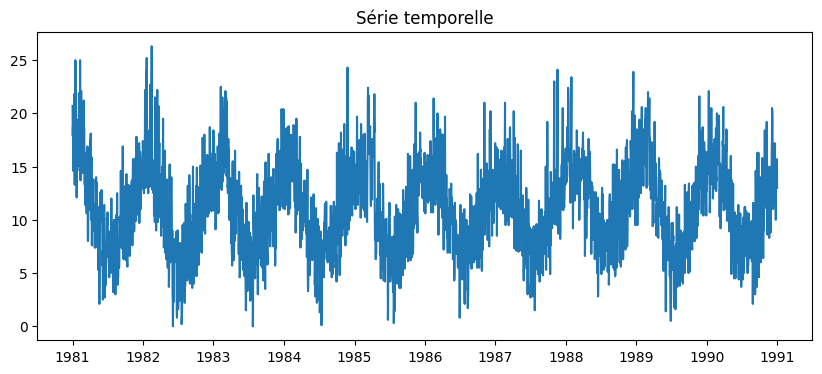

In [23]:
plt.figure(figsize=(10,4))
plt.plot(df['ds'], df['y'])
plt.title("Série temporelle")
plt.show()

#### **Définir les modèles**

In [38]:
models = [
    AutoARIMA(season_length=7),
    AutoETS(season_length=7)
]

#### **Créer l’expérience de prévision**

In [40]:
sf = StatsForecast(
 
    models=models,
    freq='MS',
    n_jobs=-1
)

#### **Ajuster les modèles**

In [41]:
sf = sf.fit(df)

#### **Prévision**

In [42]:
# h = 7   # horizon de prévision
horizon =7
level = [95]

fcst = sf.forecast(df = df,h=horizon)
fcst.head()

# forecast = sf.predict(h=h)
# forecast.head()

,unique_id,ds,AutoARIMA,AutoETS
0,Serie_1,1991-01-01,13.007904,13.749509
1,Serie_1,1991-02-01,13.497866,13.955410
2,Serie_1,1991-03-01,13.347015,14.164721
3,Serie_1,1991-04-01,13.207188,14.014120
4,Serie_1,1991-05-01,12.805756,13.742580


In [36]:
forecast = sf.predict(h=7)
forecast.head()

,unique_id,ds,AutoARIMA,AutoETS
0,Serie_1,1991-01-01,13.007904,13.749509
1,Serie_1,1991-01-02,13.497866,13.955410
2,Serie_1,1991-01-03,13.347015,14.164721
3,Serie_1,1991-01-04,13.207188,14.014120
4,Serie_1,1991-01-05,12.805756,13.742580


#### **Visualiser la prévision**

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


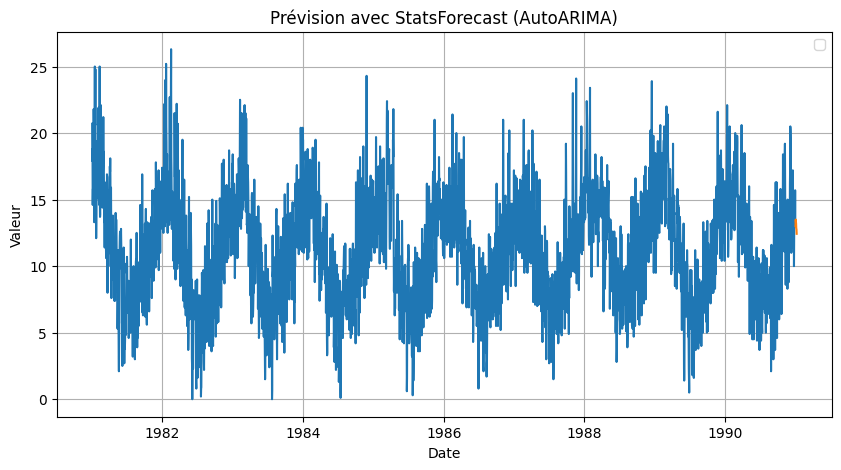

In [37]:
plt.figure(figsize=(10, 5))
# Données réelles
plt.plot(df["ds"], df["y"])
# Prévisions
plt.plot(forecast["ds"], forecast["AutoARIMA"])
# plt.axvline(x=last_date, color="gray", linestyle=":")

plt.title("Prévision avec StatsForecast (AutoARIMA)")
plt.xlabel("Date")
plt.ylabel("Valeur")
plt.legend()
plt.grid(True)

plt.show()


In [43]:
df = pd.read_csv('../data/Passenger.csv')
df['Month'] = pd.to_datetime(df['Month'])
df = df.rename(columns={
    'Month': 'ds',
    'Passengers': 'y'
})
df['unique_id'] = 'Serie_1'
df.head()

,ds,y,unique_id
0,1949-01-01,112,Serie_1
1,1949-02-01,118,Serie_1
2,1949-03-01,132,Serie_1
3,1949-04-01,129,Serie_1
4,1949-05-01,121,Serie_1


In [44]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, AutoTheta, AutoCES

In [ ]:
season_length = 12

models = [
    AutoARIMA(season_length=season_length), # ARIMA model with automatic order selection and seasonal component
    AutoETS(season_length=season_length), # ETS model with automatic error, trend, and seasonal component
    AutoTheta(season_length=season_length), # Theta model with automatic seasonality detection
    AutoCES(season_length=season_length), # CES model with automatic seasonality detection
]
sf = StatsForecast(
    models=models, # models for forecasting
    freq=pd.offsets.MonthEnd(),  # frequency of the timestamps
    n_jobs=1  # number of jobs to run in parallel, -1 means using all processors
)

In [52]:
horizon = 12
Y_hat_df = sf.forecast(df=df, h=horizon)
Y_hat_df.head()

,unique_id,ds,AutoARIMA,AutoETS,AutoTheta,CES
0,Serie_1,1960-12-31,444.309570,442.357178,442.942535,453.034180
1,Serie_1,1961-01-31,418.213745,428.267365,432.231018,429.340393
2,Serie_1,1961-02-28,446.243408,492.974792,495.307922,488.644714
3,Serie_1,1961-03-31,488.234222,477.369995,482.308014,500.289551
4,Serie_1,1961-04-30,499.237061,477.602814,487.494843,519.799622


In [53]:
sf.fit(df=df)

StatsForecast(models=[AutoARIMA,AutoETS,AutoTheta,CES])

In [54]:
Y_hat_df = sf.predict(h=horizon)

In [55]:
Y_hat_df.head()

,unique_id,ds,AutoARIMA,AutoETS,AutoTheta,CES
0,Serie_1,1960-12-31,444.309570,442.357178,442.942535,453.034180
1,Serie_1,1961-01-31,418.213745,428.267365,432.231018,429.340393
2,Serie_1,1961-02-28,446.243408,492.974792,495.307922,488.644714
3,Serie_1,1961-03-31,488.234222,477.369995,482.308014,500.289551
4,Serie_1,1961-04-30,499.237061,477.602814,487.494843,519.799622


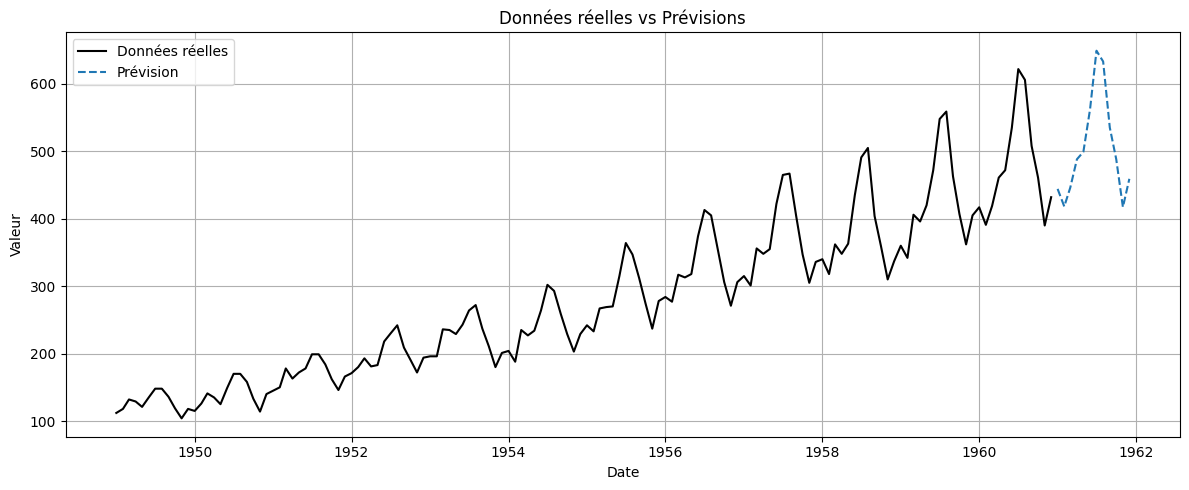

In [56]:
plt.figure(figsize=(12, 5))
plt.plot(df['ds'], df['y'], label='Données réelles', color='black')
plt.plot(
    Y_hat_df['ds'],
    Y_hat_df['AutoARIMA'],
    label='Prévision',
    linestyle='--'
)
plt.title('Données réelles vs Prévisions')
plt.xlabel('Date')
plt.ylabel('Valeur')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

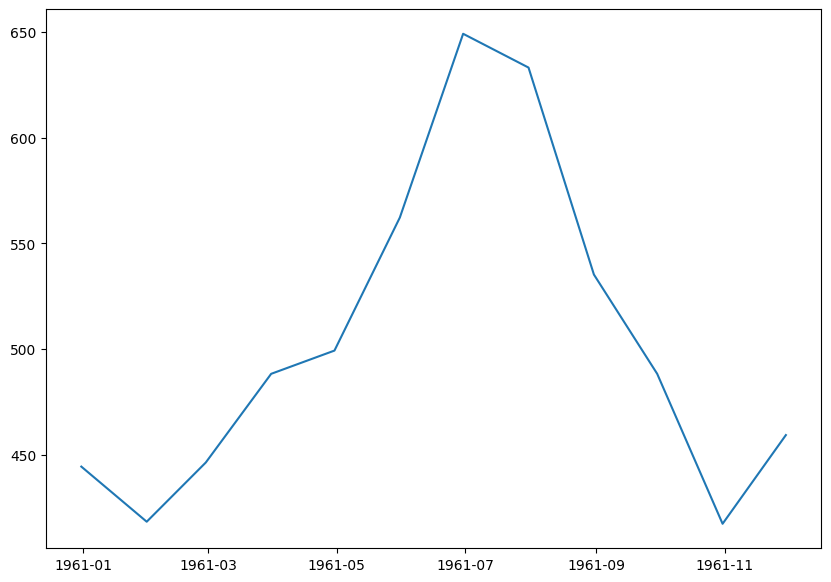

In [57]:
plt.figure(figsize=(10,7))
plt.plot(Y_hat_df['ds'],Y_hat_df['AutoARIMA'])
plt.show()

In [58]:
df = pd.read_csv("../data/meteo.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.rename(columns={
    'Date': 'ds',
    'Temp': 'y'
})
df['unique_id'] = 'Serie_1'
df.head()

,ds,y,unique_id
0,1981-01-01,20.7,Serie_1
1,1981-01-02,17.9,Serie_1
2,1981-01-03,18.8,Serie_1
3,1981-01-04,14.6,Serie_1
4,1981-01-05,15.8,Serie_1


In [59]:
models = [
    AutoARIMA(),
    AutoETS()
]

In [60]:
sf = StatsForecast(
    models=models,
    freq='D',
    n_jobs=-1
)

In [61]:
fcst = sf.forecast(df = df,h=356)
fcst.head()

,unique_id,ds,AutoARIMA,AutoETS
0,Serie_1,1991-01-01,12.829554,13.846849
1,Serie_1,1991-01-02,13.024210,13.846849
2,Serie_1,1991-01-03,13.043462,13.846849
3,Serie_1,1991-01-04,13.143480,13.846849
4,Serie_1,1991-01-05,12.862028,13.846849


In [62]:
sf.fit(df=df)

StatsForecast(models=[AutoARIMA,AutoETS])

In [63]:
predict = sf.predict(h=365)
predict.head()


,unique_id,ds,AutoARIMA,AutoETS
0,Serie_1,1991-01-01,12.829554,13.846849
1,Serie_1,1991-01-02,13.024210,13.846849
2,Serie_1,1991-01-03,13.043462,13.846849
3,Serie_1,1991-01-04,13.143480,13.846849
4,Serie_1,1991-01-05,12.862028,13.846849


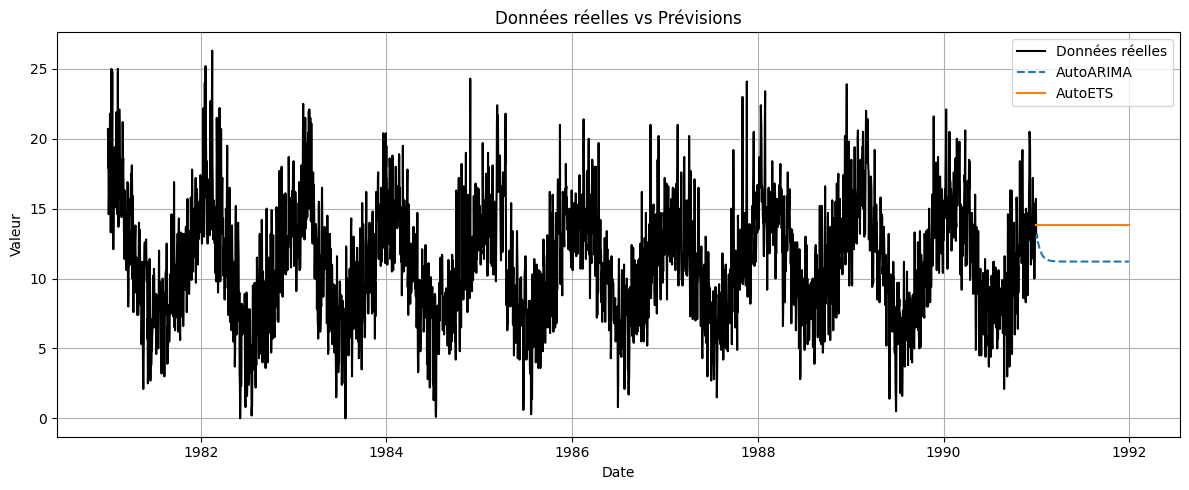

In [64]:
plt.figure(figsize=(12, 5))
plt.plot(df['ds'], df['y'], label='Données réelles', color='black')
plt.plot(
    predict['ds'],
    predict['AutoARIMA'],
    label='AutoARIMA',
    linestyle='--'
)
plt.plot(predict['ds'],predict['AutoETS'],label='AutoETS')
plt.title('Données réelles vs Prévisions')
plt.xlabel('Date')
plt.ylabel('Valeur')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [65]:
df.head()

,ds,y,unique_id
0,1981-01-01,20.7,Serie_1
1,1981-01-02,17.9,Serie_1
2,1981-01-03,18.8,Serie_1
3,1981-01-04,14.6,Serie_1
4,1981-01-05,15.8,Serie_1


In [70]:
df = pd.read_csv('../data/meteo.csv')

df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df = df.resample('M').mean()
df.head()

,Temp
Date,
1981-01-31,17.712903
1981-02-28,17.678571
1981-03-31,13.500000
1981-04-30,12.356667
1981-05-31,9.490323


In [71]:
df.shape

(120, 1)